# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [1]:
# 실습 준비 코드를 작성하세요.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"


# ============================================================
# 1. 데이터 불러오기
# ============================================================

accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")


# ============================================================
# 2. 데이터 크기 확인
# ============================================================

print("[자료 구조]")

print("accounts      :", accounts.shape)
print("subscriptions :", subscriptions.shape)
print("feature_usage :", feature_usage.shape)


# ============================================================
# 3. 상위 5개 행 확인
# ============================================================

print("\n[accounts]")
display(accounts.head())

print("\n[subscriptions]")
display(subscriptions.head())

print("\n[feature_usage]")
display(feature_usage.head())


# ============================================================
# 4. 자료형 확인
# ============================================================

print("\n[accounts 자료형]")
accounts.info()

print("\n[subscriptions 자료형]")
subscriptions.info()

print("\n[feature_usage 자료형]")
feature_usage.info()


# ============================================================
# 결측치 확인
# ============================================================

print("\n[accounts 결측치]")
print(accounts.isnull().sum())

print("\n[subscriptions 결측치]")
print(subscriptions.isnull().sum())

print("\n[feature_usage 결측치]")
print(feature_usage.isnull().sum())


# ============================================================
# 5. 날짜형 변환
# ============================================================

accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])


# ============================================================
# 6. 계정별 가장 이른 구독 만들기
# ============================================================

first_subscription = (
    subscriptions
    .sort_values("start_date")
    .drop_duplicates(
        subset="account_id",
        keep="first"
    )
    .copy()
)


print("\n[계정별 첫 구독]")
display(
    first_subscription.head()
)

print(
    "첫 구독이 존재하는 계정 수 :",
    first_subscription["account_id"].nunique()
)


# ============================================================
# 7. 기능 사용 기록 + 첫 구독 정보 결합
# ============================================================

usage_with_first_sub = feature_usage.merge(
    first_subscription[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount"
        ]
    ],
    on="subscription_id",
    how="inner"
)


# ------------------------------------------------------------
# 구독 시작 전 사용 기록
# ------------------------------------------------------------

before_start = (
    usage_with_first_sub["usage_date"]
    < usage_with_first_sub["start_date"]
)


# ------------------------------------------------------------
# 구독 종료 후 사용 기록
# ------------------------------------------------------------

after_end = (
    usage_with_first_sub["end_date"].notna()
    &
    (
        usage_with_first_sub["usage_date"]
        > usage_with_first_sub["end_date"]
    )
)


print("\n[유효 기간 밖 사용 기록]")

print(
    "구독 시작 전 :",
    before_start.sum()
)

print(
    "구독 종료 후 :",
    after_end.sum()
)


# ============================================================
# 유효 기능 사용 데이터 만들기
# ============================================================

valid_usage = usage_with_first_sub[
    (usage_with_first_sub["usage_date"]
     >= usage_with_first_sub["start_date"])
    &
    (
        usage_with_first_sub["end_date"].isna()
        |
        (usage_with_first_sub["usage_date"]
         <= usage_with_first_sub["end_date"])
    )
].copy()


print("\n[유효 기능 사용 기록]")

print(
    "전체 기록 :",
    len(usage_with_first_sub)
)

print(
    "유효 기록 :",
    len(valid_usage)
)

print(
    "제외 기록 :",
    len(usage_with_first_sub) - len(valid_usage)
)

print(
    "유효 사용 계정 수 :",
    valid_usage["account_id"].nunique()
)


# ============================================================
# 8. observation_cutoff 계산
# ============================================================

last_usage_date = feature_usage["usage_date"].max()

observation_cutoff = (
    last_usage_date
    - pd.Timedelta(days=30)
)


print("\n[관찰 기간]")

print(
    "마지막 기능 사용 날짜 :",
    last_usage_date
)

print(
    "Observation Cutoff :",
    observation_cutoff
)


[자료 구조]
accounts      : (500, 10)
subscriptions : (5000, 14)
feature_usage : (25000, 8)

[accounts]


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True



[subscriptions]


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



[feature_usage]


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



[accounts 자료형]
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB

[subscriptions 자료형]
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
4222,S-92f228,A-779e4e,2023-01-09,NaT,Basic,9,171,2052,False,False,False,False,annual,True
2920,S-50aaaa,A-af0cd2,2023-01-12,NaT,Pro,19,931,11172,False,False,False,False,monthly,True
3940,S-6676fa,A-7df7a7,2023-02-05,NaT,Pro,7,343,4116,False,False,True,False,monthly,True
3687,S-fa9b43,A-10b8f2,2023-02-05,NaT,Basic,47,0,0,True,False,False,False,annual,False
450,S-47ce2d,A-d792a6,2023-02-06,NaT,Pro,37,1813,21756,False,False,False,False,monthly,True


첫 구독이 존재하는 계정 수 : 500

[유효 기간 밖 사용 기록]
구독 시작 전 : 1471
구독 종료 후 : 47

[유효 기능 사용 기록]
전체 기록 : 2480
유효 기록 : 962
제외 기록 : 1518
유효 사용 계정 수 : 369

[관찰 기간]
마지막 기능 사용 날짜 : 2024-12-31 00:00:00
Observation Cutoff : 2024-12-01 00:00:00


---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?

#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [2]:
# 필수 1 코드를 작성하세요.

# ============================================================
# 필수 1. AARR 단계별 고유 계정 수와 전환율 계산
# ============================================================


# ============================================================
# 1. 분석 대상 계정 만들기
# signup_date <= observation_cutoff
# ============================================================

funnel_base = accounts[accounts["signup_date"] <= observation_cutoff].copy()


# 계정별 첫 구독 정보 연결
funnel_base = funnel_base.merge(
    first_subscription[
        [
            "account_id",
            "subscription_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount"
        ]
    ],
    on="account_id",
    how="left"
)


# ============================================================
# 2. 단계별 도달 여부 만들기
# ============================================================

# ------------------------------------------------------------
# Acquisition
# 분석 대상에 포함된 계정은 모두 Acquisition 도달
# ------------------------------------------------------------

funnel_base["Acquisition"] = True


# ------------------------------------------------------------
# Activation
# 가입 후 30일 이내 첫 구독 시작
# ------------------------------------------------------------

funnel_base["Activation"] = (
    funnel_base["Acquisition"]
    &
    funnel_base["start_date"].notna()
    &
    (funnel_base["start_date"] >= funnel_base["signup_date"])
    &
    (
        funnel_base["start_date"]
        <= funnel_base["signup_date"] + pd.Timedelta(days=30)
    )
)


# ------------------------------------------------------------
# Retention
# Activation 계정 중
# 첫 구독 시작 30일 후에도 기능 사용 기록이 있는 계정
# ------------------------------------------------------------

retention_ids = set(
    valid_usage.loc[
        valid_usage["usage_date"]
        >= valid_usage["start_date"] + pd.Timedelta(days=30),
        "account_id"
    ]
)


funnel_base["Retention"] = (
    funnel_base["Activation"]
    &
    funnel_base["account_id"].isin(retention_ids)
)


# ------------------------------------------------------------
# Revenue
# Retention 계정 중
# 첫 구독이 체험판이 아니고 mrr_amount > 0
# ------------------------------------------------------------

funnel_base["Revenue"] = (
    funnel_base["Retention"]
    &
    (funnel_base["is_trial_y"] == False)
    &
    (funnel_base["mrr_amount"] > 0)
)


# ============================================================
# 단계별 도달 여부 확인
# ============================================================

display(
    funnel_base[
        [
            "account_id",
            "Acquisition",
            "Activation",
            "Retention",
            "Revenue"
        ]
    ].head()
)


# ============================================================
# 3. funnel_log 만들기
# account_id / stage 형태
# ============================================================

stages = [
    "Acquisition",
    "Activation",
    "Retention",
    "Revenue"
]


funnel_log = pd.concat(
    [
        funnel_base.loc[
            funnel_base[stage],
            ["account_id"]
        ].assign(stage=stage)

        for stage in stages
    ],
    ignore_index=True
)


print("[funnel_log]")
display(funnel_log.head())


# ============================================================
# 4. 단계별 고유 계정 수 계산
# ============================================================

stage_counts = (
    funnel_log
    .groupby("stage")["account_id"]
    .nunique()
)


# ============================================================
# 5. 단계 순서 정렬
# ============================================================

stage_counts = stage_counts.reindex(
    [
        "Acquisition",
        "Activation",
        "Retention",
        "Revenue"
    ]
)


print("[단계별 고유 계정 수]")
display(stage_counts)


# ============================================================
# 6. 전환율 계산 함수
# ============================================================

def calc_conversion_rates(stage_counts):

    funnel_summary = stage_counts.reset_index()

    funnel_summary.columns = ["stage", "accounts"]


    # 전 단계 대비 전환율
    funnel_summary["step_conversion"] = (
        funnel_summary["accounts"]
        / funnel_summary["accounts"].shift(1)
    )


    # 최초 Acquisition 대비 전체 전환율
    funnel_summary["overall_conversion"] = (
        funnel_summary["accounts"]
        / funnel_summary["accounts"].iloc[0]
    )


    # Acquisition은 전 단계가 없으므로 100% 처리
    funnel_summary.loc[0, "step_conversion"] = 1


    return funnel_summary


# ============================================================
# 7. 최종 Funnel Summary
# ============================================================

funnel_summary = calc_conversion_rates(
    stage_counts
)


# 백분율 변환
funnel_summary["step_conversion_pct"] = (
    funnel_summary["step_conversion"] * 100
).round(1)


funnel_summary["overall_conversion_pct"] = (
    funnel_summary["overall_conversion"] * 100
).round(1)


display(funnel_summary)

,account_id,Acquisition,Activation,Retention,Revenue
0,A-2e4581,True,True,True,True
1,A-43a9e3,True,False,False,False
2,A-0a282f,True,True,False,False
3,A-1f0ac7,True,False,False,False
4,A-ce550d,True,True,True,True


[funnel_log]


,account_id,stage
0,A-2e4581,Acquisition
1,A-43a9e3,Acquisition
2,A-0a282f,Acquisition
3,A-1f0ac7,Acquisition
4,A-ce550d,Acquisition


[단계별 고유 계정 수]


stage
Acquisition    483
Activation     321
Retention      207
Revenue        177
Name: account_id, dtype: int64

,stage,accounts,step_conversion,overall_conversion,step_conversion_pct,overall_conversion_pct
0,Acquisition,483,1.000000,1.000000,100.0,100.0
1,Activation,321,0.664596,0.664596,66.5,66.5
2,Retention,207,0.644860,0.428571,64.5,42.9
3,Revenue,177,0.855072,0.366460,85.5,36.6


### 필수 1 답변 작성란

- **Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
    - 한 계정이 같은 기능을 여러 번 사용해도 고객은 한 계정 (중복x)

- **Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
    - Acquition 앞에는 비교할 단계가 없음, 이 단계가 퍼널 기준의 모집단임

- **Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
    - Activation을 거치지 않은 계정이 Retention에 포함되면 서로 다른 모집단을 사용하여
    - 전체적인 숫자가 맞지 않을 수 있다.

- **Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?
    - 전 단계 대비 전환율은 바로 직전 단계에서 다음 단계로 넘어온 비율
    - 전체 대비 전환율은 Acquisition(유입) 계정 중 현재 단계까지 남은 비율



1. Acquisition : 유입, 484개, 전체 500개 중 2024년 12월 1일까지 가입한 계정

2. Activation : 활성화, 위 483건 중 가입일로부터 30일 이내에 첫 활동(구독)을 시작한 계정

3. Retention : 유지, 207개, Activation에 포함, 첫 구독 시작일로부터 30일이 지난 시점에서도 유효한 기능 사용 기록이 있는 계정

4. Revenue : 수익, 177개, Retension에 포함되면서 체험판이 아니라 실제 구독료를 낸 계정

---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?

#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

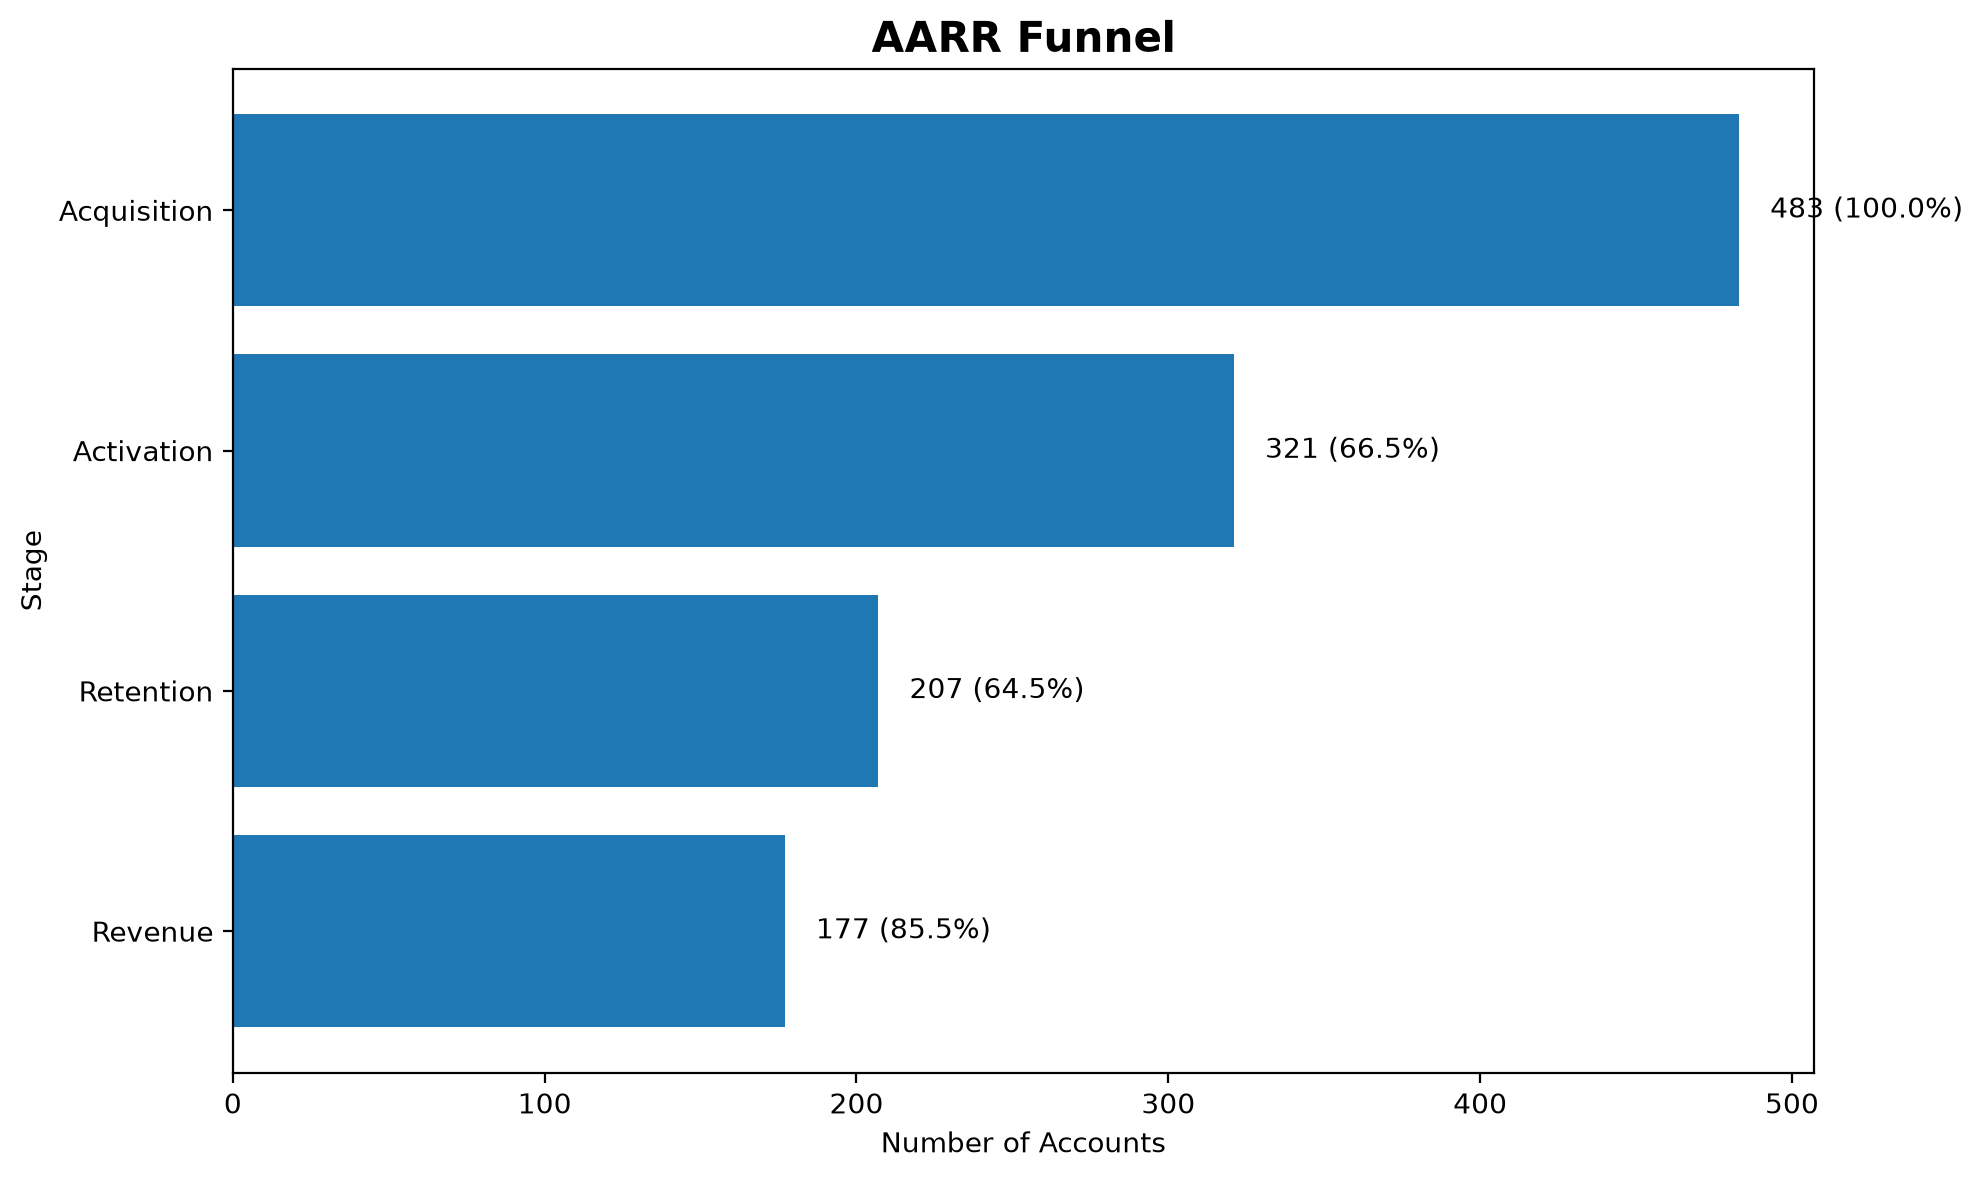

===== 가장 낮은 전환율 구간 =====
Activation → Retention
전환율 : 64.5%


In [3]:
# 필수 2 코드를 작성하세요.

# ============================================================
# 필수 2. 퍼널 시각화와 이탈 구간 찾기
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. 가로 막대그래프
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.barh(
    funnel_summary["stage"],
    funnel_summary["accounts"]
)


# ============================================================
# 2. 막대 옆에 계정 수 + 전환율 표시
# ============================================================

for bar, count, rate in zip(
    bars,
    funnel_summary["accounts"],
    funnel_summary["step_conversion_pct"]
):

    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({rate:.1f}%)",
        va="center"
    )


# 그래프 제목
plt.title(
    "AARR Funnel",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Accounts")
plt.ylabel("Stage")


# Acquisition이 위에 나오도록
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ============================================================
# 3. 첫 단계를 제외하고 가장 낮은 전환율 찾기
# ============================================================

check_df = funnel_summary.iloc[1:].copy()

lowest_idx = check_df["step_conversion"].idxmin()


lowest_stage = funnel_summary.loc[lowest_idx, "stage"]

lowest_rate = funnel_summary.loc[lowest_idx, "step_conversion_pct"]


# ============================================================
# 4. 바로 이전 단계 찾기
# ============================================================

previous_stage = funnel_summary.loc[lowest_idx - 1, "stage"]


# ============================================================
# 5. 최저 전환 구간 출력
# ============================================================

print("===== 가장 낮은 전환율 구간 =====")
print(f"{previous_stage} → {lowest_stage}")
print(f"전환율 : {lowest_rate:.1f}%")

# 가설 1: 첫 구독 후 핵심 기능의 사용방법을 충분히 익히지 못했을 수도 있습니다.
# 검증 1: 첫 30일의 기능별 사용횟수와 온보딩 완료율을 비교합니다.

### 필수 2 답변 작성란

- **Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
    - Retention 단계가 64.5%로 가장 낮음
    - 이탈구간은 Activation -> Retention

- **Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
    - 없다
    - 퍼널은 계정이 많이 줄어든 구간을 보여준다.
    - 기능, 오류, 지원 등에 대한 원인은 추가적인 데이터 분석을 통해 확인할 수 있다.

- **Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?
    - 오류 수, 오류 종류, 고객 지원, 프로모션 등을 확인할 수 있다.


---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.

#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

In [4]:
# 과제 1 코드를 작성하세요.
# 과제 1. 첫 구독 요금제별 AARR 퍼널 비교


# ============================================================
# 1. 계정별 첫 구독 만들기
# ============================================================

first_subscription = (
    subscriptions
    .sort_values("start_date")
    .drop_duplicates("account_id", keep="first")
    .copy()
)


# 필요한 컬럼만 선택
first_sub_info = first_subscription[
    [
        "account_id",
        "subscription_id",
        "start_date",
        "end_date",
        "plan_tier",
        "is_trial",
        "mrr_amount"
    ]
].copy()


# 첫 구독 정보라는 것을 알아보기 쉽게 이름 변경
first_sub_info = first_sub_info.rename(
    columns={
        "subscription_id": "first_subscription_id",
        "start_date": "first_start_date",
        "end_date": "first_end_date",
        "plan_tier": "first_plan_tier",
        "is_trial": "first_is_trial",
        "mrr_amount": "first_mrr_amount"
    }
)


# ============================================================
# 2. Acquisition 분석 대상 만들기
# ============================================================

funnel_base = accounts[
    accounts["signup_date"] <= observation_cutoff
].copy()


# 첫 구독 정보 연결
funnel_base = funnel_base.merge(
    first_sub_info,
    on="account_id",
    how="left"
)


# ============================================================
# 3. 단계별 도달 여부
# ============================================================

# Acquisition
funnel_base["Acquisition"] = True


# Activation
# 가입 후 30일 이내 첫 구독 시작
funnel_base["Activation"] = (
    funnel_base["first_start_date"].notna()
    &
    (funnel_base["first_start_date"] >= funnel_base["signup_date"])
    &
    (
        funnel_base["first_start_date"]
        <= funnel_base["signup_date"] + pd.Timedelta(days=30)
    )
)


# ------------------------------------------------------------
# Retention
# 첫 구독 시작 30일 이후에도 기능을 사용한 계정
# ------------------------------------------------------------

retention_ids = set(
    valid_usage.loc[
        valid_usage["usage_date"]
        >= valid_usage["start_date"] + pd.Timedelta(days=30),
        "account_id"
    ]
)


funnel_base["Retention"] = (
    funnel_base["Activation"]
    &
    funnel_base["account_id"].isin(retention_ids)
)


# ------------------------------------------------------------
# Revenue
# Retention 도달 +
# 첫 구독이 trial이 아니며 MRR > 0
# ------------------------------------------------------------

funnel_base["Revenue"] = (
    funnel_base["Retention"]
    &
    (funnel_base["first_is_trial"] == False)
    &
    (funnel_base["first_mrr_amount"] > 0)
)


print("[단계별 도달 여부]")
display(
    funnel_base[
        [
            "account_id",
            "first_plan_tier",
            "Acquisition",
            "Activation",
            "Retention",
            "Revenue"
        ]
    ].head()
)


# ============================================================
# 주의
# 첫 구독이 없는 계정은 plan_tier를 알 수 없으므로
# 요금제별 비교에서는 제외
# ============================================================

plan_base = funnel_base[
    funnel_base["first_plan_tier"].notna()
].copy()


# ============================================================
# 4. 요금제별 단계별 고유 계정 수
# ============================================================

plans = [
    "Basic",
    "Pro",
    "Enterprise"
]

stages = [
    "Acquisition",
    "Activation",
    "Retention",
    "Revenue"
]


result = []


for plan in plans:

    plan_data = plan_base[
        plan_base["first_plan_tier"] == plan
    ]

    for stage in stages:

        count = (
            plan_data.loc[
                plan_data[stage],
                "account_id"
            ]
            .nunique()
        )

        result.append({
            "plan_tier": plan,
            "stage": stage,
            "accounts": count
        })


plan_funnel = pd.DataFrame(result)


# ============================================================
# 5. 구간 전환율 / 이탈률 / 이탈 계정 수 계산
# ============================================================

# 같은 요금제 안에서 바로 이전 단계 계정 수
plan_funnel["previous_accounts"] = (
    plan_funnel
    .groupby("plan_tier")["accounts"]
    .shift(1)
)


# 구간 전환율
plan_funnel["conversion_rate"] = (
    plan_funnel["accounts"]
    / plan_funnel["previous_accounts"]
    * 100
)


# 이전 단계가 0이면 계산 불가
plan_funnel.loc[
    plan_funnel["previous_accounts"] == 0,
    "conversion_rate"
] = np.nan


# 이탈률
plan_funnel["dropout_rate"] = (
    100 - plan_funnel["conversion_rate"]
)


# 이탈 계정 수
plan_funnel["dropout_count"] = (
    plan_funnel["previous_accounts"]
    - plan_funnel["accounts"]
)


# 첫 단계는 이전 단계가 없으므로 NaN
plan_funnel.loc[
    plan_funnel["stage"] == "Acquisition",
    [
        "conversion_rate",
        "dropout_rate",
        "dropout_count"
    ]
] = np.nan


# 소수점 정리
plan_funnel[
    [
        "conversion_rate",
        "dropout_rate"
    ]
] = (
    plan_funnel[
        [
            "conversion_rate",
            "dropout_rate"
        ]
    ]
    .round(1)
)


print("[요금제별 Funnel]")
display(plan_funnel)

# ============================================================
# 최저 전환율 요금제 × 구간 찾기
# ============================================================

check_df = plan_funnel[
    plan_funnel["stage"] != "Acquisition"
].dropna(
    subset=["conversion_rate"]
)


lowest_idx = (
    check_df["conversion_rate"]
    .idxmin()
)


lowest = plan_funnel.loc[
    lowest_idx
]


# 현재 행의 이전 단계
plan_rows = plan_funnel[
    plan_funnel["plan_tier"]
    == lowest["plan_tier"]
].reset_index(drop=True)


current_position = (
    plan_rows[
        plan_rows["stage"] == lowest["stage"]
    ].index[0]
)


previous_stage = (
    plan_rows.loc[
        current_position - 1,
        "stage"
    ]
)


print("===== 우선 점검 구간 =====")

print(
    "요금제 :",
    lowest["plan_tier"]
)

print(
    "구간 :",
    f"{previous_stage} → {lowest['stage']}"
)

print(
    "전환율 :",
    f"{lowest['conversion_rate']:.1f}%"
)

print(
    "이탈률 :",
    f"{lowest['dropout_rate']:.1f}%"
)

print(
    "이탈 계정 수 :",
    f"{int(lowest['dropout_count']):,}개"
)

# ============================================================
# 요금제별 Revenue 최종 도달률
# ============================================================

acquisition = (
    plan_funnel[
        plan_funnel["stage"] == "Acquisition"
    ]
    [["plan_tier", "accounts"]]
    .rename(
        columns={
            "accounts": "Acquisition"
        }
    )
)


revenue = (
    plan_funnel[
        plan_funnel["stage"] == "Revenue"
    ]
    [["plan_tier", "accounts"]]
    .rename(
        columns={
            "accounts": "Revenue"
        }
    )
)


plan_summary = acquisition.merge(
    revenue,
    on="plan_tier"
)


plan_summary["Revenue_rate"] = (
    plan_summary["Revenue"]
    / plan_summary["Acquisition"]
    * 100
).round(1)


print("\n[요금제별 최종 Revenue 도달률]")
display(plan_summary)

# 추가 데이터 1 : 초기 기능 사용 행동
# 추가 데이터 2 : 오류 경험


[단계별 도달 여부]


,account_id,first_plan_tier,Acquisition,Activation,Retention,Revenue
0,A-2e4581,Pro,True,True,True,True
1,A-43a9e3,Basic,True,False,False,False
2,A-0a282f,Enterprise,True,True,False,False
3,A-1f0ac7,Pro,True,False,False,False
4,A-ce550d,Enterprise,True,True,True,True


[요금제별 Funnel]


,plan_tier,stage,accounts,previous_accounts,conversion_rate,dropout_rate,dropout_count
0,Basic,Acquisition,162,NaN,NaN,NaN,NaN
1,Basic,Activation,102,162.0,63.0,37.0,60.0
2,Basic,Retention,69,102.0,67.6,32.4,33.0
3,Basic,Revenue,57,69.0,82.6,17.4,12.0
4,Pro,Acquisition,160,NaN,NaN,NaN,NaN
5,Pro,Activation,102,160.0,63.7,36.3,58.0
6,Pro,Retention,67,102.0,65.7,34.3,35.0
7,Pro,Revenue,60,67.0,89.6,10.4,7.0
8,Enterprise,Acquisition,161,NaN,NaN,NaN,NaN
9,Enterprise,Activation,117,161.0,72.7,27.3,44.0


===== 우선 점검 구간 =====
요금제 : Enterprise
구간 : Activation → Retention
전환율 : 60.7%
이탈률 : 39.3%
이탈 계정 수 : 46개

[요금제별 최종 Revenue 도달률]


,plan_tier,Acquisition,Revenue,Revenue_rate
0,Basic,162,57,35.2
1,Pro,160,60,37.5
2,Enterprise,161,60,37.3


### 과제 1 답변 작성란

- Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?
    - Enterprise 요금제의 Activation->Retention에서 전환율이 가장 낮게 나타났다.
    - 전환율은 60.7%,
    - 이탈률은 39.3%,
    - 이탈 계정 수는 46개이다.

- Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?
    - 최종 Revenue 도달률이 가장 높은 요금제은 Pro이며 37.5%이다.
    - 최종 Revenue 도달률이 가장 낮은 요금제 Basic이며 35.2이다.
    - 두 요금제의 차이는 2.3%p이다.

- Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?
    - 우선 점검할 구간은 Enterprise의 Activation -> Retention이다(39.3% 이탈률).
    - 해당 요금제의 구간에서 초기 기능 사용은 했지만 지속해야할 필요성을 느끼지 못했을 가능성이 존재한다.
    - 검증은 기능별 사용 횟수, 사용 일수, 마지막 사용일 등을 파악하여 분석할 수 있다. 

- Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?
    - 요금제별 차이만으로 요금제가 이탈의 직접적인 원인이라고 결론 내릴 수 없다.
    - 요금제별 전환율의 연관성을 확인할 수는 있지만, 인과관계를 증명할 수는 없다.

---

## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?
    - Acquition(유입), Activation(활성화), Retention(재구독), Revenue(수익, 유료전환)

2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
    - `groupby('stage')['account_id'].nunique()`

3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
    - 전자는 바로 이전 단계에서 유지(이동)한 비율
    - 후자는 Acquistion 계정 중 현재까지 남은 비율

4. 어느 구간에서 이탈이 가장 집중되었나요?
    - 64.5% , Activation -> Retension 구간

5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
    - 퍼널은 이탈 단계를 보여주지만 이탈의 직접적인 원인은 추가 데이터로 검증이 필요하다.

6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?
    - 다른 사용자를 추천한 행동이나 추천 성공을 나타내는 이벤트가 없었다.